# Projeto Redes Neurais — Análise de Resultados

Este notebook analisa `data/results_models.csv`.

In [10]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

plt.style.use('seaborn-v0_8-whitegrid')

RESULTS_CSV_PATH = Path('data/results_models.csv')
RESULT_KEY_COLUMNS = ['model_name', 'dataset_name', 'input_type', 'used_enriched_data']
EXPECTED_COLUMNS = [
    'model_name',
    'dataset_name',
    'input_type',
    'used_enriched_data',
    'train_samples',
    'test_samples',
    'num_classes',
    'metric_average',
    'accuracy',
    'f1',
    'precision',
    'recall',
    'training_time_sec',
    'epochs',
    'image_height',
    'image_width',
]
DATASET_ORDER = ['adult income', 'student', 'statlog', 'maintenance', 'stroke']
MODEL_ORDER = [
    'XGBoost',
    'NCTD Base',
    'NCTD Attention (SE)',
    'NCTD Asymmetric Kernels',
    'NCTD Dilated Convolutions',
    'NCTD Residual',
]
VARIANT_ORDER = [
    'NCTD Attention (SE)',
    'NCTD Asymmetric Kernels',
    'NCTD Dilated Convolutions',
    'NCTD Residual',
]
INPUT_TYPE_BY_MODEL = {
    'XGBoost': 'tabular',
    'NCTD Base': 'image',
    'NCTD Attention (SE)': 'image',
    'NCTD Asymmetric Kernels': 'image',
    'NCTD Dilated Convolutions': 'image',
    'NCTD Residual': 'image',
}
SHORT_MODEL_LABELS = {
    'XGBoost': 'XGBoost',
    'NCTD Base': 'Base',
    'NCTD Attention (SE)': 'Attention',
    'NCTD Asymmetric Kernels': 'Asymmetric',
    'NCTD Dilated Convolutions': 'Dilated',
    'NCTD Residual': 'Residual',
}

## Infraestrutura compartilhada

As funções abaixo fazem a leitura do CSV, validam a grade experimental e constroem as tabelas e visualizações usadas ao longo do notebook.

In [11]:
def normalize_bool(value):
    if isinstance(value, str):
        return value.strip().lower() in {'true', '1', 'yes'}
    if pd.isna(value):
        return False
    return bool(value)


def condition_label(value):
    return 'enriched' if normalize_bool(value) else 'original'


def format_metric(value):
    if pd.isna(value):
        return '—'
    return f'{value:.3f}'


def load_and_validate_results(csv_path):
    results_df = pd.read_csv(csv_path)

    missing_columns = [column for column in EXPECTED_COLUMNS if column not in results_df.columns]
    if missing_columns:
        raise KeyError(f'CSV sem as colunas esperadas: {missing_columns}')

    results_df = results_df[EXPECTED_COLUMNS].copy()
    results_df['used_enriched_data'] = results_df['used_enriched_data'].map(normalize_bool)

    numeric_columns = [
        'train_samples',
        'test_samples',
        'num_classes',
        'accuracy',
        'f1',
        'precision',
        'recall',
        'training_time_sec',
        'epochs',
        'image_height',
        'image_width',
    ]
    for column in numeric_columns:
        results_df[column] = pd.to_numeric(results_df[column], errors='coerce')

    return results_df


def validate_experiment_grid(results_df):
    duplicates = int(results_df.duplicated(RESULT_KEY_COLUMNS).sum())

    expected_keys = {
        (model_name, dataset_name, INPUT_TYPE_BY_MODEL[model_name], enriched)
        for model_name in MODEL_ORDER
        for dataset_name in DATASET_ORDER
        for enriched in [False, True]
    }
    observed_keys = {
        (row.model_name, row.dataset_name, row.input_type, bool(row.used_enriched_data))
        for row in results_df[RESULT_KEY_COLUMNS].itertuples(index=False)
    }

    invalid_inputs = results_df[
        results_df['input_type'] != results_df['model_name'].map(INPUT_TYPE_BY_MODEL)
    ][RESULT_KEY_COLUMNS].copy()

    return {
        'duplicates': duplicates,
        'missing_keys': sorted(expected_keys - observed_keys),
        'unexpected_keys': sorted(observed_keys - expected_keys),
        'invalid_inputs': invalid_inputs,
    }


def build_f1_pivot(results_df, enriched):
    subset = results_df[results_df['used_enriched_data'] == enriched]
    return subset.pivot(index='model_name', columns='dataset_name', values='f1').reindex(
        index=MODEL_ORDER,
        columns=DATASET_ORDER,
    )


def plot_annotated_heatmap(data, title, ax=None, cmap='viridis', vmin=None, vmax=None, cbar_label='F1'):
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 5))

    image = ax.imshow(data.to_numpy(dtype=float), aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks(np.arange(data.shape[1]), labels=data.columns, rotation=25, ha='right')
    ax.set_yticks(np.arange(data.shape[0]), labels=data.index)
    ax.set_title(title)

    for row_index in range(data.shape[0]):
        for col_index in range(data.shape[1]):
            value = data.iloc[row_index, col_index]
            text = '—' if pd.isna(value) else f'{value:.3f}'
            ax.text(
                col_index,
                row_index,
                text,
                ha='center',
                va='center',
                fontsize=9,
                bbox={
                    'boxstyle': 'round,pad=0.15',
                    'facecolor': 'white',
                    'alpha': 0.65,
                    'linewidth': 0,
                },
            )

    colorbar = ax.figure.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    colorbar.set_label(cbar_label)
    return ax


def build_baseline_table(results_df):
    baseline_df = results_df[results_df['model_name'] == 'XGBoost'].copy()
    baseline_df['dataset_name'] = pd.Categorical(
        baseline_df['dataset_name'],
        categories=DATASET_ORDER,
        ordered=True,
    )
    baseline_df['data_condition'] = pd.Categorical(
        baseline_df['used_enriched_data'].map(condition_label),
        categories=['original', 'enriched'],
        ordered=True,
    )
    columns = [
        'dataset_name',
        'data_condition',
        'f1',
        'accuracy',
        'precision',
        'recall',
        'training_time_sec',
        'train_samples',
        'num_classes',
    ]
    return baseline_df[columns].sort_values(['dataset_name', 'data_condition']).reset_index(drop=True)


def build_baseline_vs_base_table(results_df):
    subset = results_df[results_df['model_name'].isin(['XGBoost', 'NCTD Base'])].copy()

    f1_pivot = subset.pivot(
        index=['dataset_name', 'used_enriched_data'],
        columns='model_name',
        values='f1',
    ).rename(columns={'XGBoost': 'xgboost_f1', 'NCTD Base': 'nctd_base_f1'})

    accuracy_pivot = subset.pivot(
        index=['dataset_name', 'used_enriched_data'],
        columns='model_name',
        values='accuracy',
    ).rename(columns={'XGBoost': 'xgboost_accuracy', 'NCTD Base': 'nctd_base_accuracy'})

    comparison_df = f1_pivot.join(accuracy_pivot).reset_index()
    comparison_df['dataset_name'] = pd.Categorical(
        comparison_df['dataset_name'],
        categories=DATASET_ORDER,
        ordered=True,
    )
    comparison_df['data_condition'] = pd.Categorical(
        comparison_df['used_enriched_data'].map(condition_label),
        categories=['original', 'enriched'],
        ordered=True,
    )
    comparison_df['delta_f1'] = comparison_df['nctd_base_f1'] - comparison_df['xgboost_f1']

    columns = [
        'dataset_name',
        'data_condition',
        'xgboost_f1',
        'nctd_base_f1',
        'delta_f1',
        'xgboost_accuracy',
        'nctd_base_accuracy',
    ]
    return comparison_df[columns].sort_values(['dataset_name', 'data_condition']).reset_index(drop=True)


def build_variant_delta_table(results_df):
    nctd_df = results_df[results_df['model_name'].isin(['NCTD Base', *VARIANT_ORDER])].copy()
    base_df = nctd_df[nctd_df['model_name'] == 'NCTD Base'][
        ['dataset_name', 'used_enriched_data', 'f1']
    ].rename(columns={'f1': 'base_f1'})

    variant_df = nctd_df.merge(base_df, on=['dataset_name', 'used_enriched_data'])
    variant_df = variant_df[variant_df['model_name'] != 'NCTD Base'].copy()
    variant_df['dataset_name'] = pd.Categorical(
        variant_df['dataset_name'],
        categories=DATASET_ORDER,
        ordered=True,
    )
    variant_df['data_condition'] = pd.Categorical(
        variant_df['used_enriched_data'].map(condition_label),
        categories=['original', 'enriched'],
        ordered=True,
    )
    variant_df['delta_f1'] = variant_df['f1'] - variant_df['base_f1']

    columns = [
        'dataset_name',
        'data_condition',
        'model_name',
        'base_f1',
        'f1',
        'delta_f1',
        'accuracy',
        'training_time_sec',
    ]
    return variant_df[columns].sort_values(
        ['data_condition', 'dataset_name', 'delta_f1'],
        ascending=[True, True, False],
    ).reset_index(drop=True)


def build_enrichment_delta_table(results_df):
    original_df = results_df[~results_df['used_enriched_data']][
        ['model_name', 'dataset_name', 'input_type', 'f1', 'accuracy']
    ].rename(columns={'f1': 'f1_original', 'accuracy': 'accuracy_original'})

    enriched_df = results_df[results_df['used_enriched_data']][
        ['model_name', 'dataset_name', 'input_type', 'f1', 'accuracy']
    ].rename(columns={'f1': 'f1_enriched', 'accuracy': 'accuracy_enriched'})

    delta_df = original_df.merge(enriched_df, on=['model_name', 'dataset_name', 'input_type'])
    delta_df['dataset_name'] = pd.Categorical(
        delta_df['dataset_name'],
        categories=DATASET_ORDER,
        ordered=True,
    )
    delta_df['delta_f1'] = delta_df['f1_enriched'] - delta_df['f1_original']
    delta_df['delta_accuracy'] = delta_df['accuracy_enriched'] - delta_df['accuracy_original']

    return delta_df.sort_values('delta_f1', ascending=False).reset_index(drop=True)


def summarize_best_models(results_df):
    best_rows = results_df.sort_values(
        ['dataset_name', 'f1', 'accuracy'],
        ascending=[True, False, False],
    ).groupby('dataset_name', as_index=False).first()

    best_xgboost = (
        results_df[results_df['model_name'] == 'XGBoost']
        .sort_values(['dataset_name', 'f1'], ascending=[True, False])
        .groupby('dataset_name', as_index=False)
        .first()[['dataset_name', 'used_enriched_data', 'f1']]
        .rename(columns={'used_enriched_data': 'best_xgboost_condition', 'f1': 'best_xgboost_f1'})
    )

    summary_df = best_rows.merge(best_xgboost, on='dataset_name')
    summary_df['dataset_name'] = pd.Categorical(
        summary_df['dataset_name'],
        categories=DATASET_ORDER,
        ordered=True,
    )
    summary_df['data_condition'] = summary_df['used_enriched_data'].map(condition_label)
    summary_df['best_xgboost_condition'] = summary_df['best_xgboost_condition'].map(condition_label)
    summary_df['delta_vs_best_xgboost'] = summary_df['f1'] - summary_df['best_xgboost_f1']
    summary_df['note'] = np.select(
        [
            summary_df['model_name'].eq('XGBoost'),
            summary_df['used_enriched_data'],
        ],
        [
            'baseline tabular lidera',
            'GAN foi necessária para o melhor resultado',
        ],
        default='modelo em imagem lidera sem GAN',
    )

    return summary_df[[
        'dataset_name',
        'model_name',
        'data_condition',
        'input_type',
        'f1',
        'accuracy',
        'delta_vs_best_xgboost',
        'training_time_sec',
        'note',
    ]].rename(columns={
        'dataset_name': 'dataset',
        'model_name': 'best_model',
        'data_condition': 'train_data',
        'input_type': 'best_input_type',
        'f1': 'best_f1',
        'accuracy': 'best_accuracy',
    }).sort_values('dataset').reset_index(drop=True)

## Checagem rápida da grade experimental

Antes da interpretação, vale confirmar se o CSV realmente cobre a grade planejada: 5 datasets, 6 modelos e 2 condições de treino para cada combinação esperada.

In [12]:
results_df = load_and_validate_results(RESULTS_CSV_PATH)
validation = validate_experiment_grid(results_df)

overview_df = pd.DataFrame({
    'item': ['rows', 'datasets', 'models', 'conditions', 'input types'],
    'value': [
        len(results_df),
        results_df['dataset_name'].nunique(),
        results_df['model_name'].nunique(),
        results_df['used_enriched_data'].nunique(),
        results_df['input_type'].nunique(),
    ],
})

counts_by_condition = (
    results_df.assign(data_condition=results_df['used_enriched_data'].map(condition_label))
    .groupby(['dataset_name', 'data_condition'])
    .size()
    .unstack(fill_value=0)
    .reindex(DATASET_ORDER)
)

model_input_contract = (
    results_df.groupby('model_name')['input_type']
    .agg(lambda values: ', '.join(sorted(set(values))))
    .reindex(MODEL_ORDER)
    .rename('input_type_contract')
    .reset_index()
)

display(overview_df)
display(counts_by_condition)
display(model_input_contract)

if validation['duplicates']:
    raise ValueError(f'Foram encontradas {validation["duplicates"]} linhas duplicadas na chave experimental.')
if validation['missing_keys']:
    raise ValueError(f'Existem combinações ausentes no CSV: {validation["missing_keys"]}')
if validation['unexpected_keys']:
    raise ValueError(f'Existem combinações inesperadas no CSV: {validation["unexpected_keys"]}')
if not validation['invalid_inputs'].empty:
    raise ValueError('Alguns modelos aparecem com input_type incompatível com o contrato experimental.')

display(Markdown('**Resultado:** a grade experimental está completa e consistente para análise.'))

,item,value
0,rows,60
1,datasets,5
2,models,6
3,conditions,2
4,input types,2


data_condition,enriched,original
dataset_name,,
adult income,6,6
student,6,6
statlog,6,6
maintenance,6,6
stroke,6,6


,model_name,input_type_contract
0,XGBoost,tabular
1,NCTD Base,image
2,NCTD Attention (SE),image
3,NCTD Asymmetric Kernels,image
4,NCTD Dilated Convolutions,image
5,NCTD Residual,image


**Resultado:** a grade experimental está completa e consistente para análise.

## Visão geral do F1

Os dois heatmaps abaixo dão uma visão rápida da história principal: qual combinação funciona melhor em dados originais e como esse quadro muda após o enriquecimento com GAN.

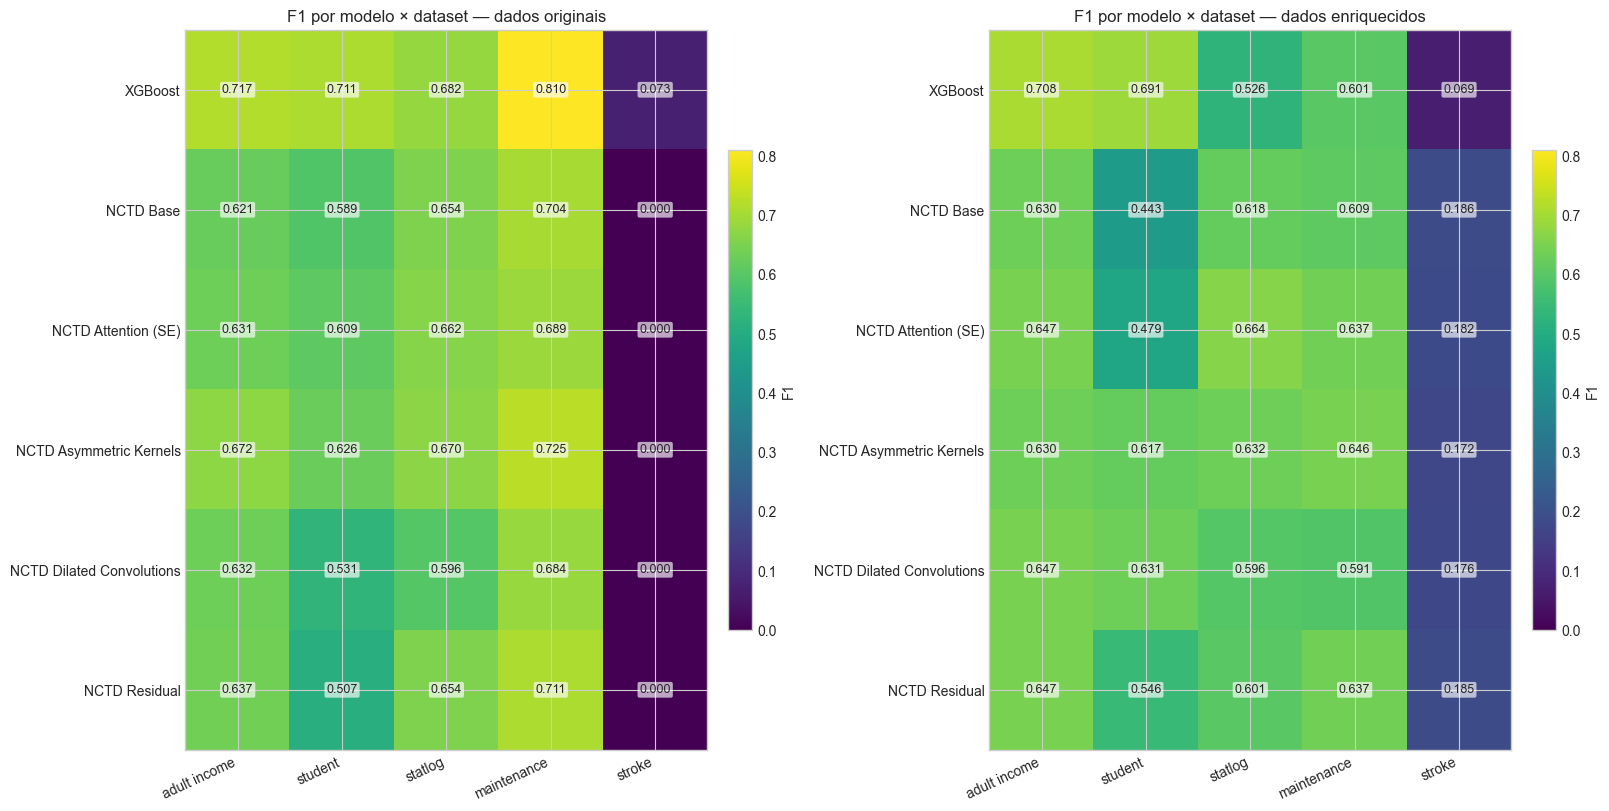

In [13]:
f1_original = build_f1_pivot(results_df, enriched=False)
f1_enriched = build_f1_pivot(results_df, enriched=True)
shared_min = min(f1_original.min().min(), f1_enriched.min().min())
shared_max = max(f1_original.max().max(), f1_enriched.max().max())

fig, axes = plt.subplots(1, 2, figsize=(16, 8), constrained_layout=True)
plot_annotated_heatmap(
    f1_original,
    title='F1 por modelo × dataset — dados originais',
    ax=axes[0],
    cmap='viridis',
    vmin=shared_min,
    vmax=shared_max,
    cbar_label='F1',
)
plot_annotated_heatmap(
    f1_enriched,
    title='F1 por modelo × dataset — dados enriquecidos',
    ax=axes[1],
    cmap='viridis',
    vmin=shared_min,
    vmax=shared_max,
    cbar_label='F1',
)
plt.show()

## Pergunta 1 — Como o baseline XGBoost se comporta nos 5 datasets?

Como referência inicial, o baseline tabular mostra o teto prático que a família NCTD precisa alcançar para ser competitiva.

In [14]:
baseline_table = build_baseline_table(results_df)
display(baseline_table.round(3))

best_baseline = baseline_table.sort_values('f1', ascending=False).iloc[0]
worst_baseline = baseline_table.sort_values('f1', ascending=True).iloc[0]
display(
    Markdown(
        f"- Melhor F1 do baseline: **{best_baseline['dataset_name']}** com dados **{best_baseline['data_condition']}** "
        f"(`F1 = {best_baseline['f1']:.3f}`).\n"
        f"- Pior caso do baseline: **{worst_baseline['dataset_name']}** com dados **{worst_baseline['data_condition']}** "
        f"(`F1 = {worst_baseline['f1']:.3f}`)."
    )
)

,dataset_name,data_condition,f1,accuracy,precision,recall,training_time_sec,train_samples,num_classes
0,adult income,original,0.717,0.877,0.800,0.649,0.223,39073,2
1,adult income,enriched,0.708,0.875,0.800,0.636,0.194,59448,2
2,student,original,0.711,0.775,0.725,0.703,0.550,3539,3
3,student,enriched,0.691,0.764,0.712,0.681,0.546,5301,3
4,statlog,original,0.682,0.998,0.693,0.672,1.077,46400,7
5,statlog,enriched,0.526,0.997,0.569,0.504,1.781,255283,7
6,maintenance,original,0.810,0.988,0.925,0.721,0.175,8000,2
7,maintenance,enriched,0.601,0.970,0.541,0.676,0.180,15458,2
8,stroke,original,0.073,0.950,0.400,0.040,0.174,4088,2
9,stroke,enriched,0.069,0.947,0.250,0.040,0.172,7778,2


- Melhor F1 do baseline: **maintenance** com dados **original** (`F1 = 0.810`).
- Pior caso do baseline: **stroke** com dados **enriched** (`F1 = 0.069`).

## Pergunta 2 — O NCTD Base do artigo se aproxima do baseline?

A comparação abaixo foca diretamente na pergunta central do trabalho: até que ponto o NCTD puro sustenta desempenho competitivo diante do baseline tabular?

model_name,dataset_name,data_condition,xgboost_f1,nctd_base_f1,delta_f1,xgboost_accuracy,nctd_base_accuracy
0,adult income,original,0.717,0.621,-0.095,0.877,0.849
1,adult income,enriched,0.708,0.630,-0.078,0.875,0.843
2,student,original,0.711,0.589,-0.122,0.775,0.617
3,student,enriched,0.691,0.443,-0.248,0.764,0.438
4,statlog,original,0.682,0.654,-0.028,0.998,0.998
5,statlog,enriched,0.526,0.618,0.092,0.997,0.998
6,maintenance,original,0.810,0.704,-0.106,0.988,0.979
7,maintenance,enriched,0.601,0.609,0.007,0.970,0.968
8,stroke,original,0.073,0.000,-0.073,0.950,0.951
9,stroke,enriched,0.069,0.186,0.117,0.947,0.888


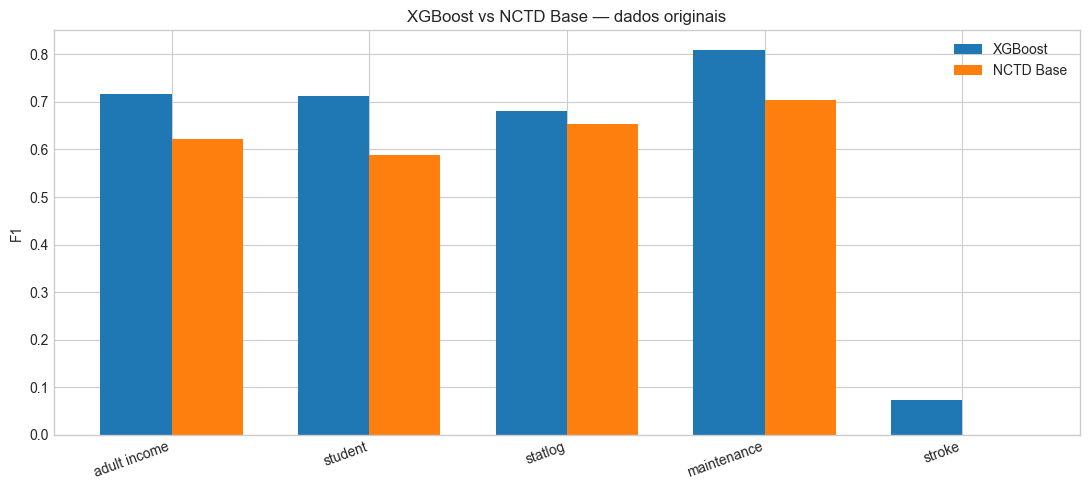

- Nos dados originais, o `NCTD Base` fica abaixo do `XGBoost` em todos os datasets.
- A menor diferença aparece em **statlog** (`delta F1 = -0.028`).

In [15]:
baseline_vs_base = build_baseline_vs_base_table(results_df)
display(baseline_vs_base.round(3))

original_compare = baseline_vs_base[baseline_vs_base['data_condition'] == 'original'].set_index('dataset_name').reindex(DATASET_ORDER)
x = np.arange(len(DATASET_ORDER))
width = 0.36

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - width / 2, original_compare['xgboost_f1'], width=width, label='XGBoost')
ax.bar(x + width / 2, original_compare['nctd_base_f1'], width=width, label='NCTD Base')
ax.set_xticks(x, DATASET_ORDER, rotation=20, ha='right')
ax.set_ylabel('F1')
ax.set_title('XGBoost vs NCTD Base — dados originais')
ax.legend()
plt.tight_layout()
plt.show()

closest_gap = original_compare['delta_f1'].idxmax()
display(
    Markdown(
        '- Nos dados originais, o `NCTD Base` fica abaixo do `XGBoost` em todos os datasets.\n'
        f"- A menor diferença aparece em **{closest_gap}** (`delta F1 = {original_compare.loc[closest_gap, 'delta_f1']:.3f}`)."
    )
)

## Pergunta 3 — As variantes do NCTD realmente melhoram o modelo original?

Aqui o objetivo não é comparar com o baseline, mas verificar se as modificações propostas trazem ganho consistente sobre o `NCTD Base`.

,dataset_name,data_condition,model_name,base_f1,f1,delta_f1,accuracy,training_time_sec
0,adult income,original,NCTD Asymmetric Kernels,0.621,0.672,0.051,0.851,435.515
1,adult income,original,NCTD Residual,0.621,0.637,0.016,0.846,417.563
2,adult income,original,NCTD Dilated Convolutions,0.621,0.632,0.011,0.849,417.589
3,adult income,original,NCTD Attention (SE),0.621,0.631,0.010,0.850,422.543
4,student,original,NCTD Asymmetric Kernels,0.589,0.626,0.037,0.677,129.468
5,student,original,NCTD Attention (SE),0.589,0.609,0.020,0.715,116.105
6,student,original,NCTD Dilated Convolutions,0.589,0.531,-0.058,0.701,108.093
7,student,original,NCTD Residual,0.589,0.507,-0.082,0.664,120.319
8,statlog,original,NCTD Asymmetric Kernels,0.654,0.670,0.016,0.998,83.913
9,statlog,original,NCTD Attention (SE),0.654,0.662,0.009,0.998,87.745


,mean,max,min
model_name,,,
NCTD Attention (SE),0.005,0.020,-0.015
NCTD Asymmetric Kernels,0.025,0.051,0.000
NCTD Dilated Convolutions,-0.025,0.011,-0.058
NCTD Residual,-0.012,0.016,-0.082


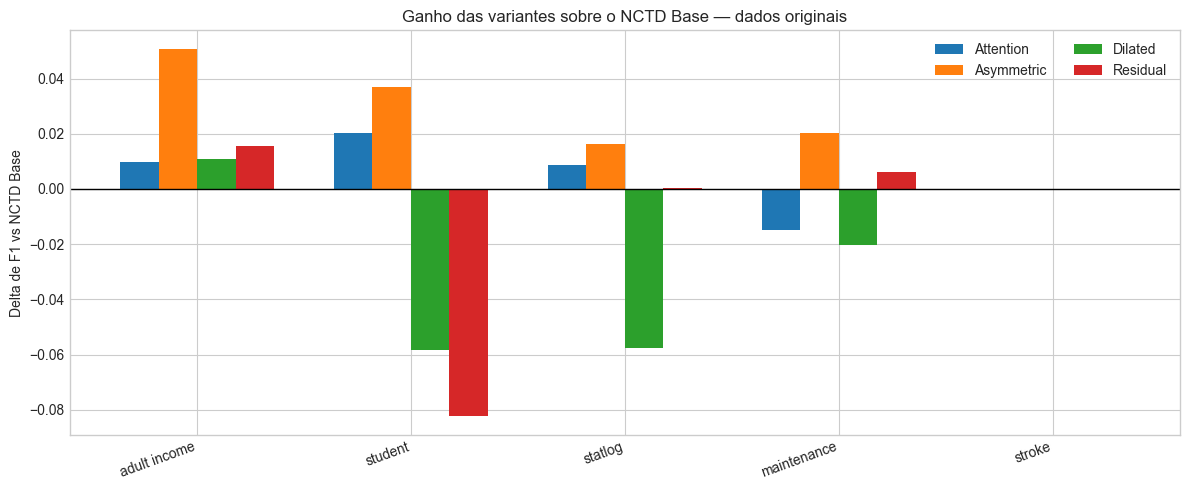

- Não aparece um vencedor universal entre as variantes.
- Nos dados originais, a melhor média de ganho sobre o `NCTD Base` fica com **NCTD Asymmetric Kernels** (`delta médio = 0.025`).

In [16]:
variant_delta_table = build_variant_delta_table(results_df)
variant_original = variant_delta_table[variant_delta_table['data_condition'] == 'original'].copy()

display(variant_original.round(3))

variant_summary = (
    variant_original.groupby('model_name')['delta_f1']
    .agg(['mean', 'max', 'min'])
    .reindex(VARIANT_ORDER)
    .round(3)
)
display(variant_summary)

x = np.arange(len(DATASET_ORDER))
width = 0.18
fig, ax = plt.subplots(figsize=(12, 5))
for idx, variant_name in enumerate(VARIANT_ORDER):
    values = (
        variant_original[variant_original['model_name'] == variant_name]
        .set_index('dataset_name')
        .reindex(DATASET_ORDER)['delta_f1']
    )
    ax.bar(
        x + (idx - 1.5) * width,
        values,
        width=width,
        label=SHORT_MODEL_LABELS[variant_name],
    )
ax.axhline(0, color='black', linewidth=1)
ax.set_xticks(x, DATASET_ORDER, rotation=20, ha='right')
ax.set_ylabel('Delta de F1 vs NCTD Base')
ax.set_title('Ganho das variantes sobre o NCTD Base — dados originais')
ax.legend(ncols=2)
plt.tight_layout()
plt.show()

best_variant = variant_summary['mean'].idxmax()
display(
    Markdown(
        '- Não aparece um vencedor universal entre as variantes.\n'
        f"- Nos dados originais, a melhor média de ganho sobre o `NCTD Base` fica com **{best_variant}** "
        f"(`delta médio = {variant_summary.loc[best_variant, 'mean']:.3f}`)."
    )
)

## Pergunta 4 — O enriquecimento com GAN melhora o F1?

Como o problema envolve desbalanceamento, esta é a parte mais importante para interpretar o efeito do enriquecimento: em quais contextos ele ajuda, em quais atrapalha e por quê.

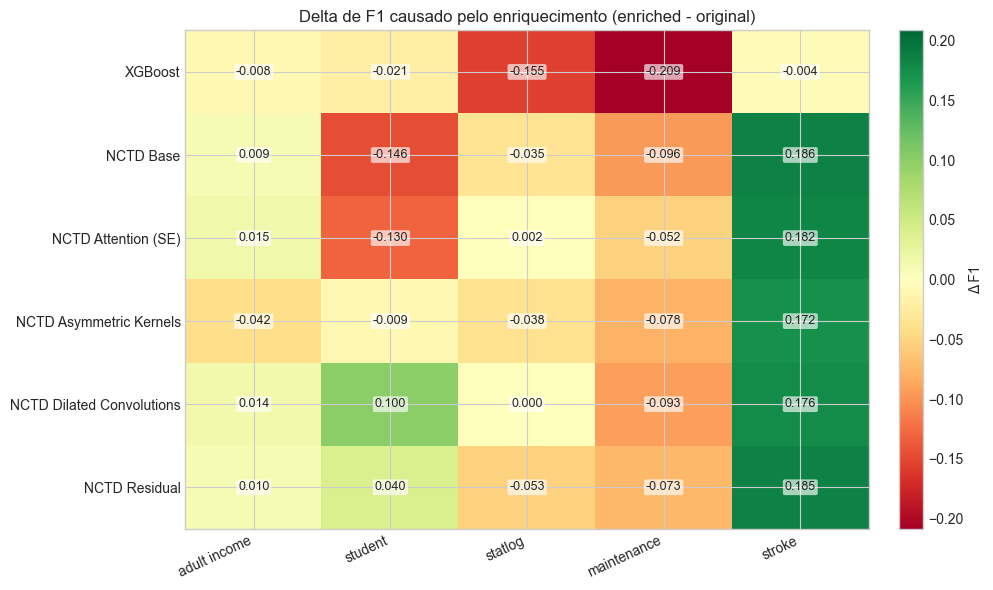

**Maiores ganhos de F1**

,dataset_name,model_name,input_type,f1_original,f1_enriched,delta_f1
0,stroke,NCTD Base,image,0.000,0.186,0.186
1,stroke,NCTD Residual,image,0.000,0.185,0.185
2,stroke,NCTD Attention (SE),image,0.000,0.182,0.182
3,stroke,NCTD Dilated Convolutions,image,0.000,0.176,0.176
4,stroke,NCTD Asymmetric Kernels,image,0.000,0.172,0.172
5,student,NCTD Dilated Convolutions,image,0.531,0.631,0.100


**Maiores perdas de F1**

,dataset_name,model_name,input_type,f1_original,f1_enriched,delta_f1
29,maintenance,XGBoost,tabular,0.810,0.601,-0.209
28,statlog,XGBoost,tabular,0.682,0.526,-0.155
27,student,NCTD Base,image,0.589,0.443,-0.146
26,student,NCTD Attention (SE),image,0.609,0.479,-0.130
25,maintenance,NCTD Base,image,0.704,0.609,-0.096
24,maintenance,NCTD Dilated Convolutions,image,0.684,0.591,-0.093


**Stroke: accuracy alta pode mascarar F1 muito baixo**

,model_name,train_data,accuracy,f1
48,XGBoost,original,0.950,0.073
50,NCTD Base,original,0.951,0.000
52,NCTD Attention (SE),original,0.951,0.000
54,NCTD Asymmetric Kernels,original,0.951,0.000
56,NCTD Dilated Convolutions,original,0.951,0.000
58,NCTD Residual,original,0.951,0.000
51,NCTD Base,enriched,0.888,0.186
59,NCTD Residual,enriched,0.880,0.185
53,NCTD Attention (SE),enriched,0.833,0.182
57,NCTD Dilated Convolutions,enriched,0.890,0.176


In [17]:
enrichment_delta_table = build_enrichment_delta_table(results_df)
delta_heatmap = enrichment_delta_table.pivot(index='model_name', columns='dataset_name', values='delta_f1').reindex(
    index=MODEL_ORDER,
    columns=DATASET_ORDER,
)
abs_max = float(np.nanmax(np.abs(delta_heatmap.to_numpy(dtype=float))))

fig, ax = plt.subplots(figsize=(10, 6))
plot_annotated_heatmap(
    delta_heatmap,
    title='Delta de F1 causado pelo enriquecimento (enriched - original)',
    ax=ax,
    cmap='RdYlGn',
    vmin=-abs_max,
    vmax=abs_max,
    cbar_label='Δ F1',
)
plt.tight_layout()
plt.show()

top_gains = enrichment_delta_table[
    ['dataset_name', 'model_name', 'input_type', 'f1_original', 'f1_enriched', 'delta_f1']
].head(6)
top_losses = enrichment_delta_table[
    ['dataset_name', 'model_name', 'input_type', 'f1_original', 'f1_enriched', 'delta_f1']
].sort_values('delta_f1').head(6)

display(Markdown('**Maiores ganhos de F1**'))
display(top_gains.round(3))
display(Markdown('**Maiores perdas de F1**'))
display(top_losses.round(3))

stroke_focus = results_df[results_df['dataset_name'] == 'stroke'][
    ['model_name', 'used_enriched_data', 'accuracy', 'f1']
].copy()
stroke_focus['train_data'] = pd.Categorical(
    stroke_focus['used_enriched_data'].map(condition_label),
    categories=['original', 'enriched'],
    ordered=True,
)
stroke_focus = stroke_focus[['model_name', 'train_data', 'accuracy', 'f1']].sort_values(
    ['train_data', 'f1'],
    ascending=[True, False],
)
display(Markdown('**Stroke: accuracy alta pode mascarar F1 muito baixo**'))
display(stroke_focus.round(3))

## Tempo de treinamento

O gráfico abaixo adiciona a leitura de custo computacional à história principal: quanto tempo cada experimento levou para treinar e qual `F1` ele entregou. Assim, fica mais fácil ver quando um ganho de desempenho vem acompanhado de um custo muito maior.

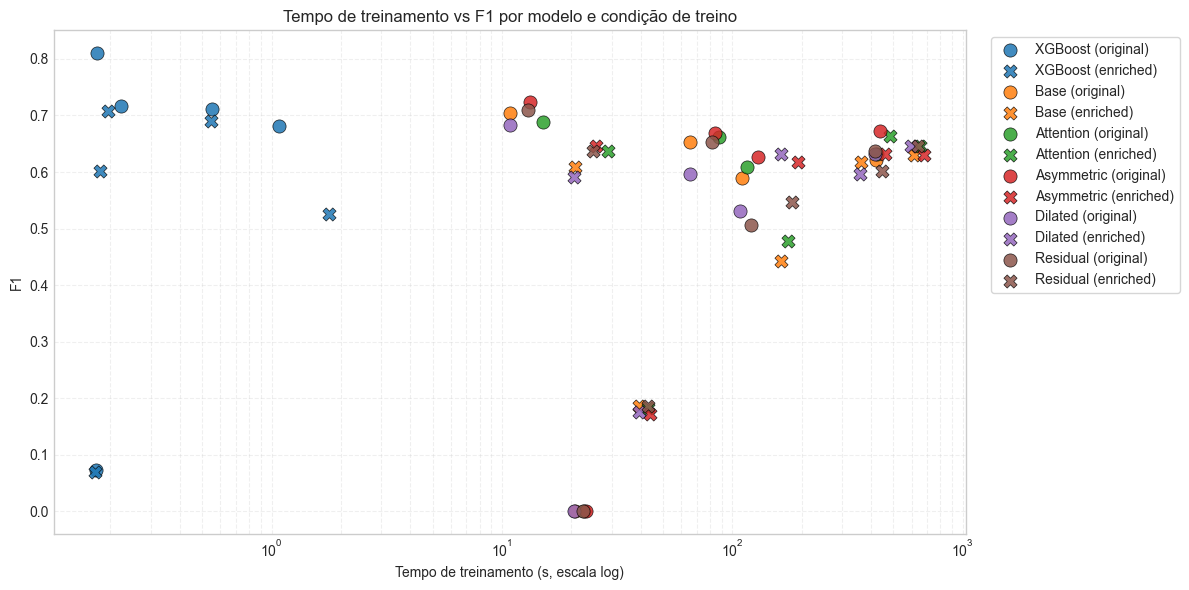

In [18]:
plot_df = results_df.copy()
plot_df['data_condition'] = plot_df['used_enriched_data'].map(condition_label)
plot_df['marker'] = plot_df['data_condition'].map({'original': 'o', 'enriched': 'X'})
color_map = {
    'XGBoost': '#1f77b4',
    'NCTD Base': '#ff7f0e',
    'NCTD Attention (SE)': '#2ca02c',
    'NCTD Asymmetric Kernels': '#d62728',
    'NCTD Dilated Convolutions': '#9467bd',
    'NCTD Residual': '#8c564b',
}

fig, ax = plt.subplots(figsize=(12, 6))
for model_name in MODEL_ORDER:
    for data_condition, marker in [('original', 'o'), ('enriched', 'X')]:
        subset = plot_df[
            (plot_df['model_name'] == model_name)
            & (plot_df['data_condition'] == data_condition)
        ]
        if subset.empty:
            continue

        label = f"{SHORT_MODEL_LABELS[model_name]} ({data_condition})"
        ax.scatter(
            subset['training_time_sec'],
            subset['f1'],
            s=90,
            alpha=0.85,
            marker=marker,
            color=color_map[model_name],
            edgecolor='black',
            linewidth=0.5,
            label=label,
        )

ax.set_xscale('log')
ax.set_xlabel('Tempo de treinamento (s, escala log)')
ax.set_ylabel('F1')
ax.set_title('Tempo de treinamento vs F1 por modelo e condição de treino')
ax.grid(True, which='both', linestyle='--', alpha=0.3)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

## Consolidação final

A tabela final resume o melhor resultado por dataset e ajuda a fechar a narrativa para apresentação.

In [19]:
summary_table = summarize_best_models(results_df)
display(summary_table.round(3))

original_compare = baseline_vs_base[baseline_vs_base['data_condition'] == 'original'].set_index('dataset_name').reindex(DATASET_ORDER)
variant_means = variant_original.groupby('model_name')['delta_f1'].mean().sort_values(ascending=False)
best_gain = enrichment_delta_table.iloc[0]
worst_loss = enrichment_delta_table.sort_values('delta_f1').iloc[0]
xgboost_wins = int(summary_table['best_model'].eq('XGBoost').sum())
image_wins = int(summary_table['best_input_type'].eq('image').sum())

display(
    Markdown(
        f"- **Baseline:** o `XGBoost` entrega o melhor resultado final em **{xgboost_wins} de 5** datasets.\n"
        f"- **NCTD puro:** nos dados originais, o `NCTD Base` fica abaixo do baseline em todos os datasets; a menor diferença aparece em **{original_compare['delta_f1'].idxmax()}**.\n"
        f"- **Variantes:** não há vencedor global; a melhor média de ganho sobre o `NCTD Base` nos dados originais é de **{variant_means.index[0]}** (`delta médio = {variant_means.iloc[0]:.3f}`).\n"
        f"- **GAN enrichment:** o maior ganho de `F1` aparece em **{best_gain['dataset_name']} / {best_gain['model_name']}** (`delta = {best_gain['delta_f1']:.3f}`), enquanto a maior perda ocorre em **{worst_loss['dataset_name']} / {worst_loss['model_name']}** (`delta = {worst_loss['delta_f1']:.3f}`).\n"
        f"- **Leitura final:** modelos em imagem lideram apenas **{image_wins}** dataset(s), e o caso de `stroke` reforça por que `accuracy` sozinha não é suficiente para julgar desempenho em cenários desbalanceados."
    )
)

,dataset,best_model,train_data,best_input_type,best_f1,best_accuracy,delta_vs_best_xgboost,training_time_sec,note
0,adult income,XGBoost,original,tabular,0.717,0.877,0.000,0.223,baseline tabular lidera
1,student,XGBoost,original,tabular,0.711,0.775,0.000,0.550,baseline tabular lidera
2,statlog,XGBoost,original,tabular,0.682,0.998,0.000,1.077,baseline tabular lidera
3,maintenance,XGBoost,original,tabular,0.810,0.988,0.000,0.175,baseline tabular lidera
4,stroke,NCTD Base,enriched,image,0.186,0.888,0.113,39.227,GAN foi necessária para o melhor resultado


- **Baseline:** o `XGBoost` entrega o melhor resultado final em **4 de 5** datasets.
- **NCTD puro:** nos dados originais, o `NCTD Base` fica abaixo do baseline em todos os datasets; a menor diferença aparece em **statlog**.
- **Variantes:** não há vencedor global; a melhor média de ganho sobre o `NCTD Base` nos dados originais é de **NCTD Asymmetric Kernels** (`delta médio = 0.025`).
- **GAN enrichment:** o maior ganho de `F1` aparece em **stroke / NCTD Base** (`delta = 0.186`), enquanto a maior perda ocorre em **maintenance / XGBoost** (`delta = -0.209`).
- **Leitura final:** modelos em imagem lideram apenas **1** dataset(s), e o caso de `stroke` reforça por que `accuracy` sozinha não é suficiente para julgar desempenho em cenários desbalanceados.